In [117]:
import gym
import d4rl
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
def return_range(dataset, max_episode_steps):
    returns, lengths = [], []
    ep_ret, ep_len = 0., 0
    for r, d in zip(dataset['rewards'], dataset['terminals']):
        ep_ret += float(r)
        ep_len += 1
        if d or ep_len == max_episode_steps:
            returns.append(ep_ret)
            lengths.append(ep_len)
            ep_ret, ep_len = 0., 0
    # returns.append(ep_ret)    # incomplete trajectory
    lengths.append(ep_len)      # but still keep track of number of steps
    assert sum(lengths) == len(dataset['rewards'])
    return min(returns), max(returns)


def get_env_and_dataset(env_name, max_episode_steps=1000):
    env = gym.make(env_name)
    dataset = d4rl.qlearning_dataset(env)

    if any(s in env_name for s in ('halfcheetah', 'hopper', 'walker2d')):
        min_ret, max_ret = return_range(dataset, max_episode_steps)
        dataset['rewards'] /= (max_ret - min_ret)
        dataset['rewards'] *= max_episode_steps
    elif 'antmaze' in env_name:
        dataset['rewards'] -= 1.

    for k, v in dataset.items():
        dataset[k] = torch.from_numpy(v).to(device)

    return env, dataset

In [3]:
ENV_NAME = 'halfcheetah-medium-expert-v2'
env, dataset = get_env_and_dataset(ENV_NAME)

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
load datafile: 100%|██████████| 9/9 [00:02<00:00,  3.03it/s]


In [13]:
obs_dim = dataset['observations'].shape[1]
act_dim = dataset['actions'].shape[1] 

In [25]:
class Squeeze(nn.Module):
    def __init__(self, dim=None):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        return x.squeeze(dim=self.dim)

def mlp(dims, activation=nn.ReLU, output_activation=None, squeeze_output=False):
    n_dims = len(dims)
    assert n_dims >= 2, 'MLP requires at least two dims (input and output)'

    layers = []
    for i in range(n_dims - 2):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        layers.append(activation())
    layers.append(nn.Linear(dims[-2], dims[-1]))
    if output_activation is not None:
        layers.append(output_activation())
    if squeeze_output:
        assert dims[-1] == 1
        layers.append(Squeeze(-1))
    net = nn.Sequential(*layers)
    net.to(dtype=torch.float32)
    return net

In [38]:
from torch.distributions import MultivariateNormal

LOG_STD_MIN = -5.0
LOG_STD_MAX = 2.0

class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        self.net = mlp([obs_dim, *([hidden_dim] * n_hidden), act_dim])
        self.log_std = nn.Parameter(torch.zeros(act_dim, dtype=torch.float32))

    def forward(self, obs):
        mean = self.net(obs)
        std = torch.exp(self.log_std.clamp(LOG_STD_MIN, LOG_STD_MAX))
        scale_tril = torch.diag(std)
        return MultivariateNormal(mean, scale_tril=scale_tril)


    def act(self, obs, deterministic=False, enable_grad=False):
        with torch.set_grad_enabled(enable_grad):
            dist = self(obs)
            return dist.mean if deterministic else dist.sample()
        
        
class TwinQ(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        dims = [state_dim + action_dim, *([hidden_dim] * n_hidden), 1]
        self.q1 = mlp(dims, squeeze_output=True)
        self.q2 = mlp(dims, squeeze_output=True)

    def both(self, state, action):
        sa = torch.cat([state, action], 1)
        return self.q1(sa), self.q2(sa)

    def forward(self, state, action):
        return torch.min(*self.both(state, action))


class ValueFunction(nn.Module):
    def __init__(self, state_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        dims = [state_dim, *([hidden_dim] * n_hidden), 1]
        self.v = mlp(dims, squeeze_output=True)

    def forward(self, state):
        return self.v(state)

In [85]:
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR


class IQL(nn.Module):
    def __init__(self, critic, value, policy, optimizer_factory, max_steps):
        super().__init__()
        self.critic = critic.to(device)
        self.target_critic = copy.deepcopy(critic).requires_grad_(False).to(device)
        self.value = value.to(device)
        self.policy = policy.to(device)
        self.v_optimizer = optimizer_factory(self.value.parameters())
        self.q_optimizer = optimizer_factory(self.critic.parameters())
        self.policy_optimizer = optimizer_factory(self.policy.parameters())
        self.policy_lr_schedule = CosineAnnealingLR(self.policy_optimizer, max_steps)

In [98]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

In [91]:
def asymmetric_l2_loss(u, tau):
    return torch.mean(torch.abs(tau - (u < 0).float()) * u**2)

def update_exponential_moving_average(target, source, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)

def sample_batch(dataset, batch_size):
    k = list(dataset.keys())[0]
    n, device = len(dataset[k]), dataset[k].device
    for v in dataset.values():
        assert len(v) == n, 'Dataset values must have same length'
    indices = torch.randint(low=0, high=n, size=(batch_size,), device=device)
    return {k: v[indices] for k, v in dataset.items()}

In [113]:
def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]


def evaluate_policy(env, iql_agent, max_episode_steps=1000):
    obs = env.reset()
    total_reward = 0.
    for _ in range(max_episode_steps):
        with torch.no_grad():
            obs = torch.tensor(obs, device=device, dtype=torch.float)
            action = iql_agent.policy.act(obs, deterministic=True).cpu().numpy()
        next_obs, reward, done, info = env.step(action)
        total_reward += reward
        if done:
            break
        else:
            obs = next_obs
    return total_reward

In [120]:
policy = GaussianPolicy(obs_dim, act_dim).to(device)
critic = TwinQ(obs_dim, act_dim)
value = ValueFunction(obs_dim)

iql_agent = IQL(
    critic=critic,
    value=value,
    policy=policy,
    optimizer_factory=lambda params: torch.optim.Adam(params, lr=3e-4),
    max_steps=10**6,
)

actor_losses = []
v_losses = []
q_losses = []
rewards_logs = []

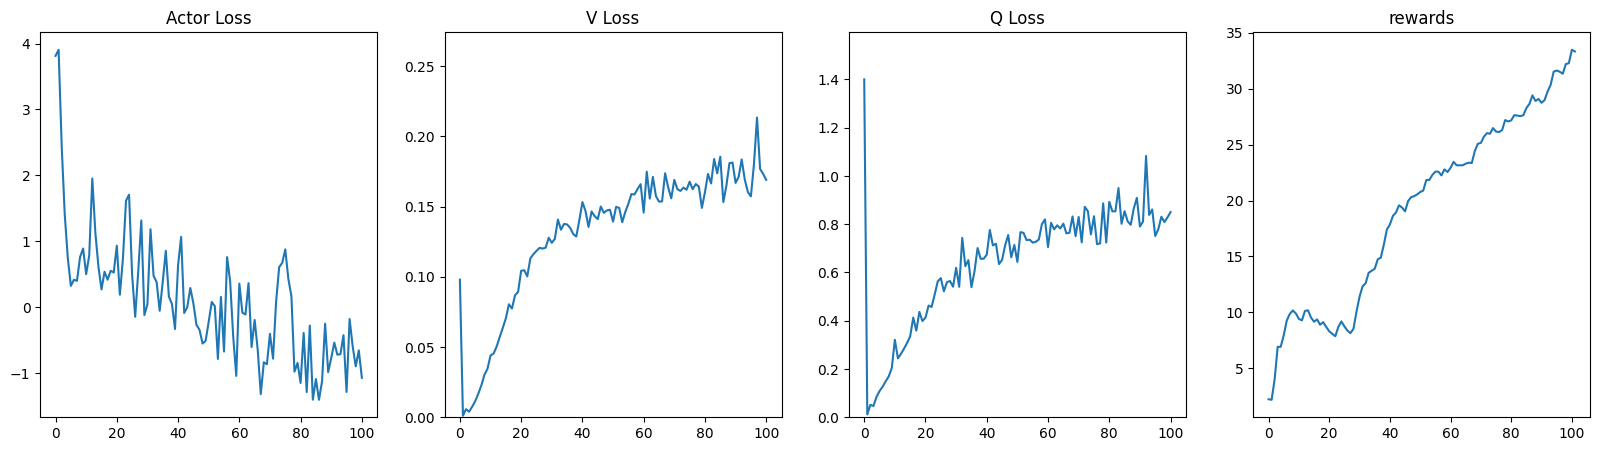

 10%|█         | 101539/1000000 [12:34<1:51:13, 134.64it/s]


KeyboardInterrupt: 

In [121]:

for timestep in tqdm(range(10**6)):

    batch = sample_batch(dataset, 256)


    observations, actions, next_observations, rewards, terminals = batch.values()

    with torch.no_grad():
        target_q = iql_agent.target_critic(observations, actions)
        next_v = iql_agent.value(next_observations)

    # Update value function
    v = iql_agent.value(observations)
    adv = target_q - v
    v_loss = asymmetric_l2_loss(adv, config['expectile'])
    iql_agent.v_optimizer.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.v_optimizer.step()



    # Update Q function
    targets = rewards + (1. - terminals.float()) * config['discount'] * next_v.detach()
    qs = iql_agent.critic.both(observations, actions)
    q_loss = sum(F.mse_loss(q, targets) for q in qs) / len(qs)
    iql_agent.q_optimizer.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.q_optimizer.step()

    # Update target Q network
    update_exponential_moving_average(iql_agent.target_critic, iql_agent.critic, config['tau'])

    # Update policy
    exp_adv = torch.exp(config['temperature'] * adv.detach()).clamp(max=100.)
    policy_out = iql_agent.policy(observations)
    if isinstance(policy_out, torch.distributions.Distribution):
        bc_losses = -policy_out.log_prob(actions)
    elif torch.is_tensor(policy_out):
        assert policy_out.shape == actions.shape
        bc_losses = torch.sum((policy_out - actions)**2, dim=1)
    else:
        raise NotImplementedError
    policy_loss = torch.mean(exp_adv * bc_losses)
    iql_agent.policy_optimizer.zero_grad(set_to_none=True)
    policy_loss.backward()
    iql_agent.policy_optimizer.step()
    iql_agent.policy_lr_schedule.step()
    
    
    
    actor_losses.append(policy_loss.item())
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    
    
    
    if timestep % 1000 == 0:
        
        eval_returns = np.array([evaluate_policy(env, iql_agent) for _ in range(10)])
        normalized_returns = d4rl.get_normalized_score(ENV_NAME, eval_returns) * 100.0
        
        rewards_logs.append(normalized_returns.mean())
        
        clear_output(True)
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        axs[1].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(rewards_logs))
        axs[3].set_title("rewards")
        
        plt.show()

In [76]:
dataset['terminals'].any()

tensor(False, device='cuda:0')